#Random Forest and Feature Selection

## Introduction

Previous experiments investigated how different aspects of data quality influence machine learning performance.

In this experiment, the focus is on feature selection and its influence on a Random Forest classifier.

Three different feature sets will be compared:

- Basic Features
- Extended Features
- All Features

The objective is to determine whether the choice and number of input features affect the performance of the Random Forest model.

## Import Libraries

The following libraries are required for data preprocessing, model training, evaluation, and visualization.

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

## Load the Dataset

The Titanic dataset used in the previous experiments is loaded again to ensure consistency between the experiments.

The same dataset and preprocessing approach are used so that the results can be compared fairly with the previous models.

In [12]:
df = pd.read_csv("Titanic-Dataset.csv")


## Data Preprocessing

The dataset is prepared using the same preprocessing procedure used in the previous experiments.

Missing values in Age and Embarked are handled, categorical variables are converted into numerical features, and unnecessary columns are removed.

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df,columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

## Feature Selection

Three different feature sets are created to investigate how feature selection affects Random Forest performance.

Basic Features contain the main passenger characteristics.

Extended Features include additional information that may provide useful predictive patterns.

All Features contain all available processed features.

In [14]:
basic_features = ["Pclass", "Age","SibSp","Parch","Fare"]

extended_features = ["Pclass","Age","SibSp", "Parch","Fare","Sex_male"]

all_features = [column for column in df.columns
if column != "Survived"]

feature_sets = {"Basic Features": basic_features,"Extended Features": extended_features,"All Features": all_features}


## Train and Evaluate Random Forest

A separate Random Forest classifier is trained for each feature set.

The same train-test split and random state are used for all experiments to ensure a fair comparison.

Accuracy, Precision, Recall, F1-score, and confusion matrix values are calculated for each feature configuration.

In [15]:
results = []

for name, features in feature_sets.items():

    X = df[features]
    y = df["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42 )

    model = RandomForestClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()

    results.append({
        "Feature Set": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp})

## Results

The results from the three feature configurations are combined into a single table.

This table allows the performance of the Random Forest model to be compared across different feature sets.

In [16]:
comparison = pd.DataFrame(results)

comparison = comparison.round(3)

comparison

,Feature Set,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,Basic Features,0.721,0.682,0.608,0.643,84,21,29,45
1,Extended Features,0.810,0.786,0.743,0.764,90,15,19,55
2,All Features,0.821,0.800,0.757,0.778,91,14,18,56


## Accuracy Comparison

The following graph compares the Accuracy of the Random Forest model across the three feature sets.

The graph illustrates how the overall classification performance changes when additional features are included.

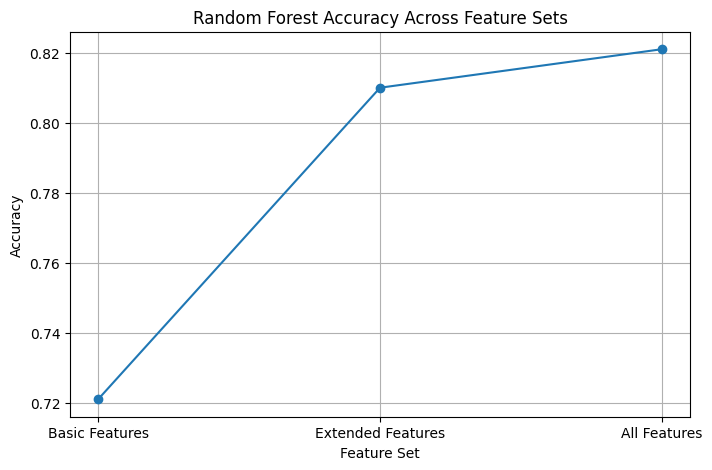

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(comparison["Feature Set"],comparison["Accuracy"], marker="o")

plt.xlabel("Feature Set")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy Across Feature Sets")

plt.grid(True)

plt.savefig("random_forest_feature_selection_accuracy.png")

plt.show()

## F1-score Comparison

The following graph compares the F1-score of the Random Forest model across the three feature sets.

The F1-score provides a balanced measure of Precision and Recall and helps evaluate the overall quality of the classification results.

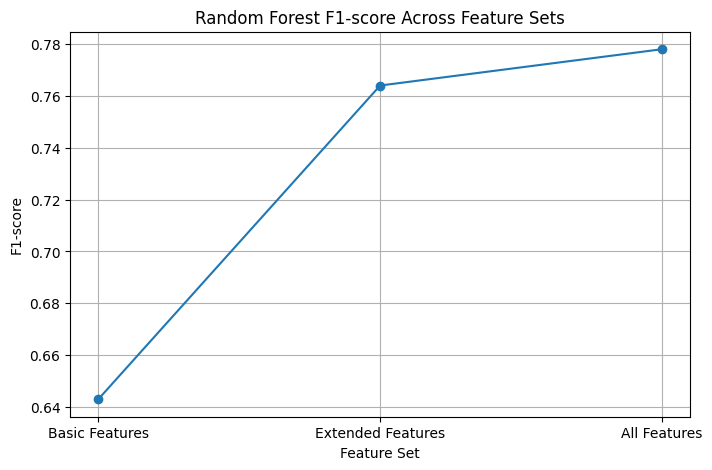

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(comparison["Feature Set"],comparison["F1-score"],marker="o")

plt.xlabel("Feature Set")
plt.ylabel("F1-score")
plt.title("Random Forest F1-score Across Feature Sets")

plt.grid(True)

plt.savefig("random_forest_feature_selection_f1.png")

plt.show()

## Analysis of Results

The results show a clear improvement in Random Forest performance when additional informative features are included.

The Basic Features configuration produced the lowest performance, with an Accuracy of 0.721 and an F1-score of 0.643.

The Extended Features configuration improved the results substantially, reaching an Accuracy of 0.810 and an F1-score of 0.764.

The All Features configuration achieved the best overall performance, with an Accuracy of 0.821 and an F1-score of 0.778.

Compared with the Basic Features configuration, using All Features increased Accuracy by 0.100 and F1-score by 0.135.

The results indicate that the additional features provided useful information for the Random Forest model. Unlike the Decision Tree experiment, where performance also improved with additional features, Random Forest achieved a particularly strong result when all available features were used.

Overall, the experiment demonstrates that feature selection can have a significant effect on model performance, and that the optimal feature set depends on the machine learning algorithm and dataset.

## Conclusion

This experiment investigated the effect of feature selection on the performance of a Random Forest classifier using the Titanic dataset.

Three feature configurations were compared: Basic Features, Extended Features, and All Features.

The Basic Features configuration achieved an Accuracy of 0.721 and an F1-score of 0.643, while the All Features configuration achieved the highest Accuracy of 0.821 and the highest F1-score of 0.778.

These results show that including additional informative features significantly improved Random Forest performance in this experiment.

Therefore, for this dataset and Random Forest model, using all available processed features produced the strongest classification performance.